<a href="https://colab.research.google.com/github/SattuSupCodes/PythonJournal/blob/main/workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch Workflow


In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

In [ ]:
#  data (preparing and loading)

weight = 0.7
bias = 0.3

#create
start = 0
end = 1
step = 0.02
x = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * x + bias

x[:10],y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(x),len(y)

(50, 50)

In [ ]:
#splitting data

train_split = int(0.8*len(x))
x_train,y_train = x[:train_split],y[:train_split]
x_test  ,y_test   = x[train_split:],y[train_split:]

len(x_train),len(y_train),len(x_test),len(y_test)

(40, 40, 10, 10)

# Visualizing

In [ ]:
def plot(x_train,y_train,x_test,y_test,predictions=None):
  plt.figure(figsize=(10,7))
  plt.scatter(  x_train,y_train,c="b",s=4,label="Training Data")
  plt.scatter(  x_test,y_test,c="g",s=4,label="Testing Data")
  if predictions is not None:
    plt.scatter(x_test,predictions, c="r", s=4, label="preds")
  plt.legend(prop={"size":14})

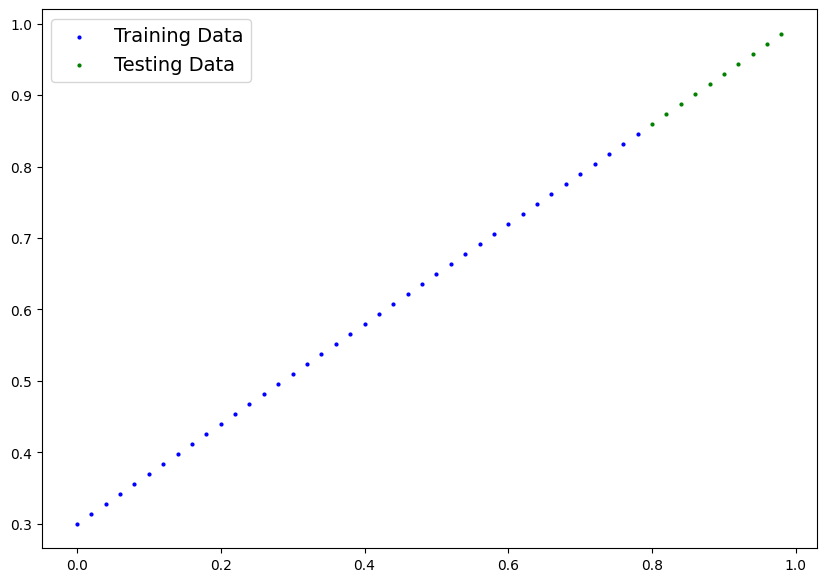

In [ ]:
plot(x_train,y_train,x_test,y_test);

#Model
nn module contain all the building blocks for neural networks

initialise model parameters to be used in varous computatons (these coul be different layers from torch .nn, single parameters, hard-coded values or functions)

requires_gradient = True means PyTorch will track the gradients of this specific parameter for use with torch.autograd and gradient descent (for many torch.nn modules, requires_grad = True is set by default)

Any subclass of nn.Module needs to override forward()
(this defines the forward computation of the model)

In [ ]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.rand(1,
                                           requires_grad=True,
                                           dtype=torch.float))
    self.bias = nn.Parameter(torch.rand(1,
                                        requires_grad = True,
                                        dtype=torch.float))
  def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.weights * x + self.bias

# PyTorch model building essentials

1. torch.nn -> contains building blocks for neural networks

2. torch.nn.Parameter -> what params should the model try and learn

3. torch.nn.Module -> the base class for all neural network module, if u subclass it u should overwrite forward()

4. torch.optim -> optimizers in PyTorch, they will help with gradient descent

5. def forward() -> all nn.Module subclasses require u to overwrite. This method defines what happens in the forward computation.

In [ ]:
#creating a random seed

torch.manual_seed(42)

#creating an instance of the model (this is a subclass of nn.Module)

model_0 = LinearRegression()
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

#Making predictions


In [ ]:
with torch.inference_mode():
  y_preds = model_0(x_test)
y_preds


tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [ ]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

<function __main__.plot(x_train, y_train, x_test, y_test, predictions=None)>

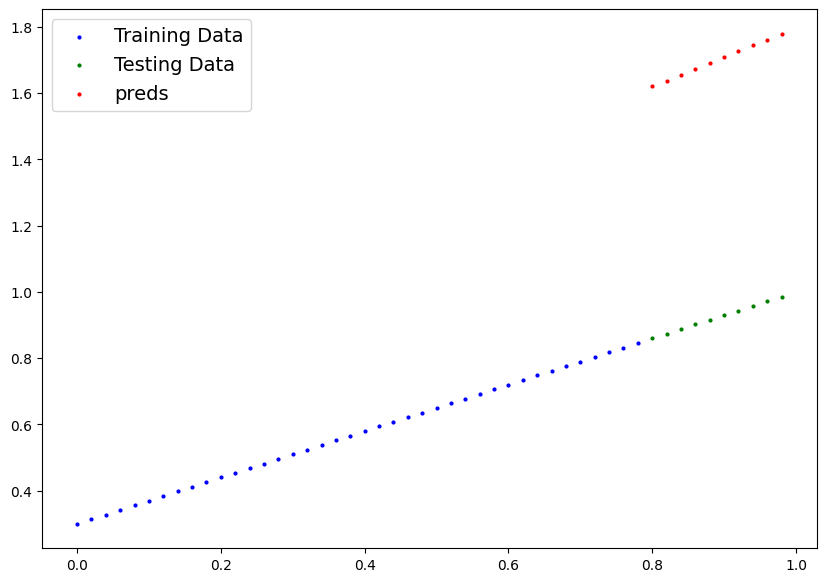

In [ ]:
plot(x_train,y_train,x_test,y_test, predictions = y_preds)
plot

# Learning Loops

one way to measure how poor model's preds are we can use loss functions.



